In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
from sklearn.ensemble import AdaBoostRegressor 
from sklearn.ensemble import RandomForestRegressor 


Memasukkan Data

In [2]:
no2_mks = pd.read_csv('data/NO2.csv')
no2_jkt = pd.read_csv('data/NO2_jakarta.csv')
no2_jpr = pd.read_csv('data/NO2_jayapura.csv')
no2_bndg = pd.read_csv('data/NO2_bandung.csv')
no2_bks = pd.read_csv('data/no2_bekasi.csv')
no2_bgr = pd.read_csv('data/no2_bogor.csv')
no2_gsk = pd.read_csv('data/no2_gresik.csv')
no2_smrng = pd.read_csv('data/no2_semarang.csv')
no2_srg = pd.read_csv('data/no2_serang.csv')
no2_srby = pd.read_csv('data/no2_surabaya.csv')
no2_skt = pd.read_csv('data/no2_surakarta.csv')
no2_ykt = pd.read_csv('data/no2_yogyakarta.csv')


In [3]:
#Mengecek apakah data sudah terbaca
no2_mks.head()

,system:time_start,p25,Median,IQR,Left date,Right date
0,"Jul 11, 2018",NaN,NaN,NaN,0.0,NaN
1,"Jul 11, 2018",16.464,19.174,22.623,NaN,NaN
2,"Jul 20, 2018",14.510,18.971,24.103,NaN,NaN
3,"Jul 29, 2018",14.333,19.078,23.014,NaN,NaN
4,"Aug 7, 2018",11.150,15.799,22.005,NaN,NaN


Membuat fungsi untuk Memproses Data

In [4]:
def process_dataframe(df, suffix):
    # Rename columns
    df_renamed = df.rename(columns={
        'system:time_start': f'date_{suffix}',
        'p25': f'pm25_{suffix}',
        'Median': f'md_{suffix}',
        'IQR': f'IQR_{suffix}'
    })
    
    # Menghilangkan Data yang Tidak Penting
    df_dropped = df_renamed.drop(['Left date', 'Right date'], axis=1)
    
    return df_dropped

# list data yang ingin didefinisikan
dfs = [
    (no2_mks, 'mks'),
    (no2_jkt, 'jkt'),
    (no2_jpr, 'jpr'),
    (no2_bndg, 'bndg'),
    (no2_bks, 'bks'),
    (no2_bgr, 'bgr'),
    (no2_gsk, 'gsk'),
    (no2_smrng, 'smrng'),
    (no2_srg, 'srg'),
    (no2_srby, 'srby'),
    (no2_skt, 'skt'),
    (no2_ykt, 'ykt')
]

# Process each dataframe
processed_dfs = {suffix: process_dataframe(df, suffix) for df, suffix in dfs}

# Memproses Data untuk disaring
no2_mks_processed = processed_dfs['mks']
no2_jkt_processed = processed_dfs['jkt']
no2_jpr_processed = processed_dfs['jpr']
no2_bndg_processed = processed_dfs['bndg']
no2_bks_processed = processed_dfs['bks']
no2_bgr_processed = processed_dfs['bgr']
no2_gsk_processed = processed_dfs['gsk']
no2_smrng_processed = processed_dfs['smrng']
no2_srg_processed = processed_dfs['srg']
no2_srby_processed = processed_dfs['srby']
no2_skt_processed = processed_dfs['skt']
no2_ykt_processed = processed_dfs['ykt']

#drop data yang tidak diperlukan
no2_jkt_4 = no2_jkt_processed.drop(['date_jkt'],axis=1)
no2_jpr_4 = no2_jpr_processed.drop(['date_jpr'],axis=1)
no2_bndg_4 = no2_bndg_processed.drop(['date_bndg'],axis=1)
no2_bks_4 = no2_bks_processed.drop(['date_bks'],axis=1)
no2_bgr_4 = no2_bgr_processed.drop(['date_bgr'],axis=1)
no2_gsk_4 = no2_gsk_processed.drop(['date_gsk'],axis=1)
no2_smrng_4 = no2_smrng_processed.drop(['date_smrng'],axis=1)
no2_srg_4 = no2_srg_processed.drop(['date_srg'],axis=1)
no2_srby_4 = no2_srby_processed.drop(['date_srby'],axis=1)
no2_skt_4 = no2_skt_processed.drop(['date_skt'],axis=1)
no2_ykt_4 = no2_ykt_processed.drop(['date_ykt'],axis=1) 


In [5]:
no2_mks_processed.head()

,date_mks,pm25_mks,md_mks,IQR_mks
0,"Jul 11, 2018",NaN,NaN,NaN
1,"Jul 11, 2018",16.464,19.174,22.623
2,"Jul 20, 2018",14.510,18.971,24.103
3,"Jul 29, 2018",14.333,19.078,23.014
4,"Aug 7, 2018",11.150,15.799,22.005


Menyimpan Data

In [6]:
result_merge1 = pd.merge(no2_mks_processed, no2_jkt_4, left_index=True, right_index=True)
result_merge2 = pd.merge(result_merge1, no2_jpr_4, left_index=True, right_index=True)
result_merge3 = pd.merge(result_merge2, no2_bks_4, left_index=True, right_index=True)
result_merge4 = pd.merge(result_merge3, no2_bgr_4, left_index=True, right_index=True)
result_merge5 = pd.merge(result_merge4, no2_gsk_4, left_index=True, right_index=True)
result_merge6 = pd.merge(result_merge5, no2_srby_4, left_index=True, right_index=True)
result_merge7 = pd.merge(result_merge6, no2_smrng_4, left_index=True, right_index=True)
result_merge8 = pd.merge(result_merge7, no2_srg_4, left_index=True, right_index=True)
result_merge9 = pd.merge(result_merge8, no2_skt_4, left_index=True, right_index=True)
result_merge10 = pd.merge(result_merge9, no2_bndg_4, left_index=True, right_index=True)
polusi = pd.merge(result_merge10, no2_ykt_4, left_index=True, right_index=True)
polusi.head(10).T
polusi.to_csv('polusi2.csv')

In [7]:
def rename_column(df_in, cn1, cn2, cn3, cn4):
    df_out = df_in.rename(columns={'system:time_start': cn1, 'p25': cn2, 'Median': cn3, 'IQR': cn4})
    df_out = df_out.drop(['Left date', 'Right date'],axis=1)
    
no2_mks_3 = rename_column(no2_mks, 'date_mks', 'pm25_mks', 'md_mks', 'IQR_mks')


In [8]:
polusi.head()

,date_mks,pm25_mks,md_mks,IQR_mks,pm25_jkt,md_jkt,IQR_jkt,pm25_jpr,md_jpr,IQR_jpr,...,IQR_srg,pm25_skt,md_skt,IQR_skt,pm25_bndg,md_bndg,IQR_bndg,pm25_ykt,md_ykt,IQR_ykt
0,"Jul 11, 2018",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Jul 11, 2018",16.464,19.174,22.623,94.241,97.761,101.281,6.661,6.661,6.661,...,47.881,25.193,32.204,41.276,45.082,50.529,56.584,12.971,18.000,22.665
2,"Jul 20, 2018",14.510,18.971,24.103,92.277,97.096,108.599,4.229,5.988,8.118,...,47.471,42.513,50.276,59.682,44.307,48.338,52.683,20.028,25.324,30.628
3,"Jul 29, 2018",14.333,19.078,23.014,121.386,142.954,162.276,7.002,9.754,12.483,...,89.203,27.074,34.332,40.286,37.365,49.420,60.905,15.363,20.847,26.261
4,"Aug 7, 2018",11.150,15.799,22.005,83.540,87.479,91.421,0.762,3.996,8.098,...,105.336,22.866,27.860,34.001,50.676,52.019,53.117,13.397,17.066,21.431


In [10]:
polusi.head()

,date_mks,pm25_mks,md_mks,IQR_mks,pm25_jkt,md_jkt,IQR_jkt,pm25_jpr,md_jpr,IQR_jpr,...,pm25_skt,md_skt,IQR_skt,pm25_bndg,md_bndg,IQR_bndg,pm25_ykt,md_ykt,IQR_ykt,date
0,"Jul 11, 2018",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-11
1,"Jul 11, 2018",16.464,19.174,22.623,94.241,97.761,101.281,6.661,6.661,6.661,...,25.193,32.204,41.276,45.082,50.529,56.584,12.971,18.000,22.665,2018-07-11
2,"Jul 20, 2018",14.510,18.971,24.103,92.277,97.096,108.599,4.229,5.988,8.118,...,42.513,50.276,59.682,44.307,48.338,52.683,20.028,25.324,30.628,2018-07-20
3,"Jul 29, 2018",14.333,19.078,23.014,121.386,142.954,162.276,7.002,9.754,12.483,...,27.074,34.332,40.286,37.365,49.420,60.905,15.363,20.847,26.261,2018-07-29
4,"Aug 7, 2018",11.150,15.799,22.005,83.540,87.479,91.421,0.762,3.996,8.098,...,22.866,27.860,34.001,50.676,52.019,53.117,13.397,17.066,21.431,2018-08-07


In [11]:
##polusi = pd.read_csv("POLUSI1.csv", delimiter=';')

In [12]:
polusi.head()

,date_mks,pm25_mks,md_mks,IQR_mks,pm25_jkt,md_jkt,IQR_jkt,pm25_jpr,md_jpr,IQR_jpr,...,pm25_skt,md_skt,IQR_skt,pm25_bndg,md_bndg,IQR_bndg,pm25_ykt,md_ykt,IQR_ykt,date
0,"Jul 11, 2018",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-11
1,"Jul 11, 2018",16.464,19.174,22.623,94.241,97.761,101.281,6.661,6.661,6.661,...,25.193,32.204,41.276,45.082,50.529,56.584,12.971,18.000,22.665,2018-07-11
2,"Jul 20, 2018",14.510,18.971,24.103,92.277,97.096,108.599,4.229,5.988,8.118,...,42.513,50.276,59.682,44.307,48.338,52.683,20.028,25.324,30.628,2018-07-20
3,"Jul 29, 2018",14.333,19.078,23.014,121.386,142.954,162.276,7.002,9.754,12.483,...,27.074,34.332,40.286,37.365,49.420,60.905,15.363,20.847,26.261,2018-07-29
4,"Aug 7, 2018",11.150,15.799,22.005,83.540,87.479,91.421,0.762,3.996,8.098,...,22.866,27.860,34.001,50.676,52.019,53.117,13.397,17.066,21.431,2018-08-07


In [13]:
DATA_INFO= pd.to_datetime(polusi['date_mks'])
print(DATA_INFO)

0     2018-07-11
1     2018-07-11
2     2018-07-20
3     2018-07-29
4     2018-08-07
         ...    
235   2024-04-07
236   2024-04-16
237   2024-04-25
238   2024-05-04
239   2024-05-13
Name: date_mks, Length: 240, dtype: datetime64[ns]


In [14]:
date_time=pd.concat([DATA_INFO], axis=1)

In [15]:
data= pd.DataFrame()

In [16]:
data['Date']=pd.to_datetime(date_time['date_mks'])

In [17]:
polutan = ['IQR_mks', 'IQR_jkt', 'IQR_jpr', 'IQR_bndg', 'IQR_bks', 'IQR_bgr', 'IQR_gsk', 'IQR_smrng', 'IQR_srg', 'IQR_srby', 'IQR_skt', 'IQR_ykt']

Membuat Scatter Plot untuk Data

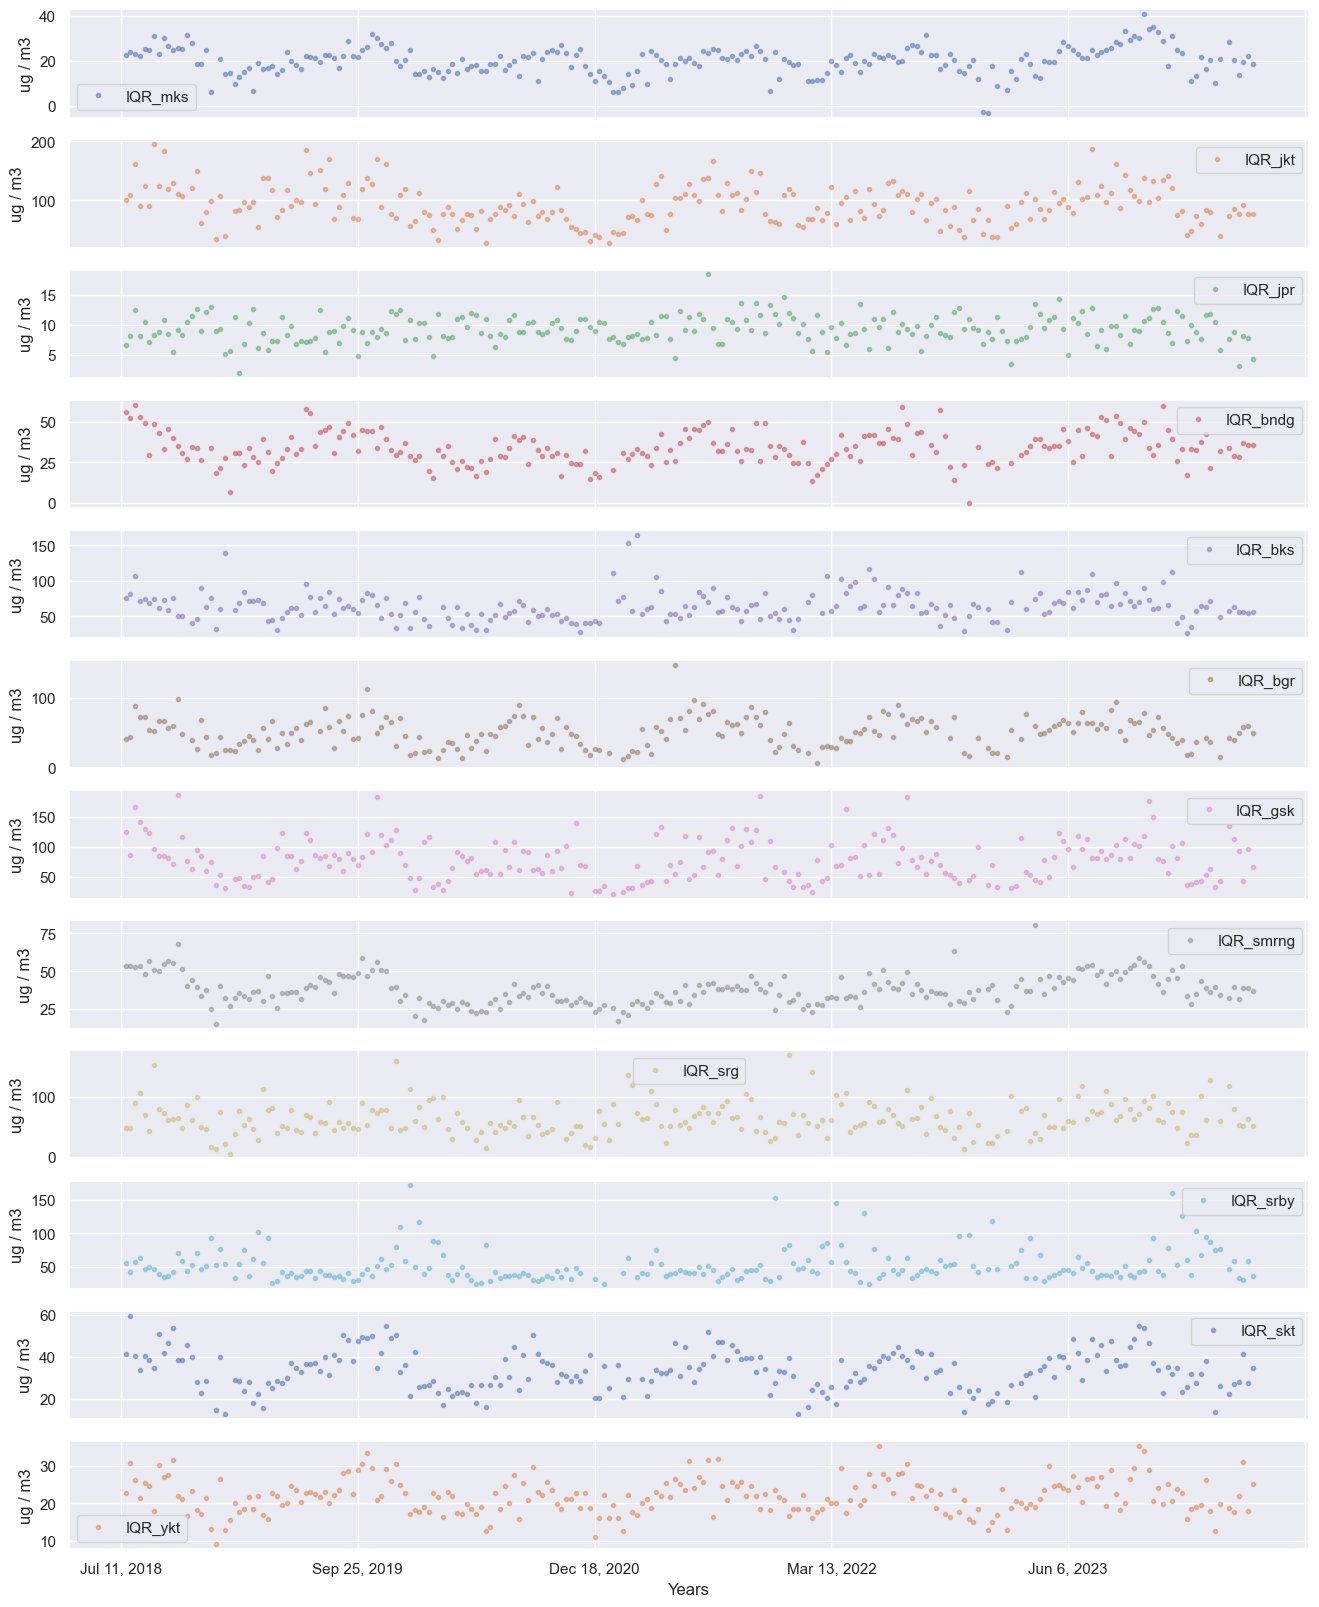

In [18]:
polusi.set_index('date_mks',inplace=True)
axes = polusi[polutan].plot(marker='.', alpha=0.5, linestyle='None', figsize=(16, 20), subplots=True)
for ax in axes:
    
    ax.set_xlabel('Years')
    ax.set_ylabel('ug / m3')

Membuat Figure Time Series Plot

In [19]:
def trend_plot(dataframe,value):
    
    # Prepare data
    polusi['year'] = [d.year for d in data.Date]
    polusi['month'] = [d.strftime('%b') for d in polusi.Date]
    years = polusi['year'].unique()

    # Draw Plot
    fig, axes = plt.subplots(1, 2, figsize=(14,6), dpi= 80)
    sns.boxplot(x='year', y=value, data=polusi, ax=axes[0])
    sns.pointplot(x='month', y=value, data=df.loc[polusi.year.isin([2015, 2020]), :])

    # Set Title
    axes[0].set_title('Year-wise Box Plot \n(The Trend)', fontsize=18); 
    axes[1].set_title('Month-wise Plot \n(The Seasonality)', fontsize=18)
    plt.show()

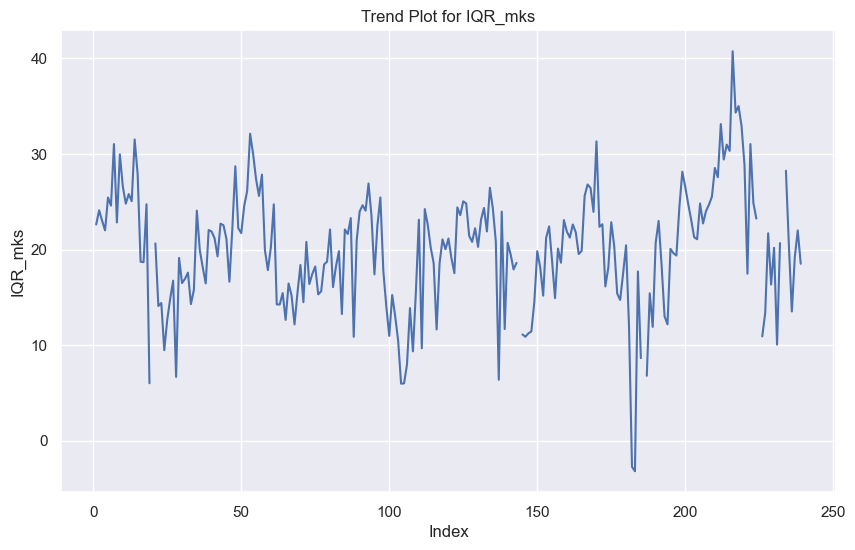

In [20]:
# Resetting index
polusi.reset_index(inplace=True)

# Creating a copy
df = polusi.copy()

# Defining the trend_plot function
def trend_plot(dataframe, column_name):
    plt.figure(figsize=(10, 6))
    plt.plot(dataframe.index, dataframe[column_name])
    plt.xlabel('Index')
    plt.ylabel(column_name)
    plt.title(f'Trend Plot for {column_name}')
    plt.grid(True)
    plt.show()

# Calling the trend_plot function
value = 'IQR_mks'
trend_plot(df, value)


In [21]:
date_time ['ds'] = date_time['date_mks'].astype(str)

In [22]:
data['ds'] = pd.to_datetime(date_time['ds'])
data.head()

,Date,ds
0,2018-07-11,2018-07-11
1,2018-07-11,2018-07-11
2,2018-07-20,2018-07-20
3,2018-07-29,2018-07-29
4,2018-08-07,2018-08-07


In [23]:
data['y']=polusi['IQR_mks']
data.head()

,Date,ds,y
0,2018-07-11,2018-07-11,NaN
1,2018-07-11,2018-07-11,22.623
2,2018-07-20,2018-07-20,24.103
3,2018-07-29,2018-07-29,23.014
4,2018-08-07,2018-08-07,22.005


In [24]:
from prophet import Prophet
model = Prophet()
model.fit(data)

13:31:15 - cmdstanpy - INFO - Chain [1] start processing
13:31:15 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
future = model.make_future_dataframe(periods=365, freq='h')
future.tail()

,ds
594,2024-05-28 01:00:00
595,2024-05-28 02:00:00
596,2024-05-28 03:00:00
597,2024-05-28 04:00:00
598,2024-05-28 05:00:00


In [26]:
forecast = model.predict(future)
forecast [['ds', 'yhat','yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
594,2024-05-28 01:00:00,24.442909,18.515863,30.228694
595,2024-05-28 02:00:00,24.451063,18.514334,29.959849
596,2024-05-28 03:00:00,24.459190,18.768561,30.180692
597,2024-05-28 04:00:00,24.467291,18.653180,29.976527
598,2024-05-28 05:00:00,24.475365,18.680229,30.320475


c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:72: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:73: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ax.plot(m.history['ds'].dt.to_pydatetime(), m.history['y'], 'k.',


Text(0.5, 0.98, 'IQR_Makassar')

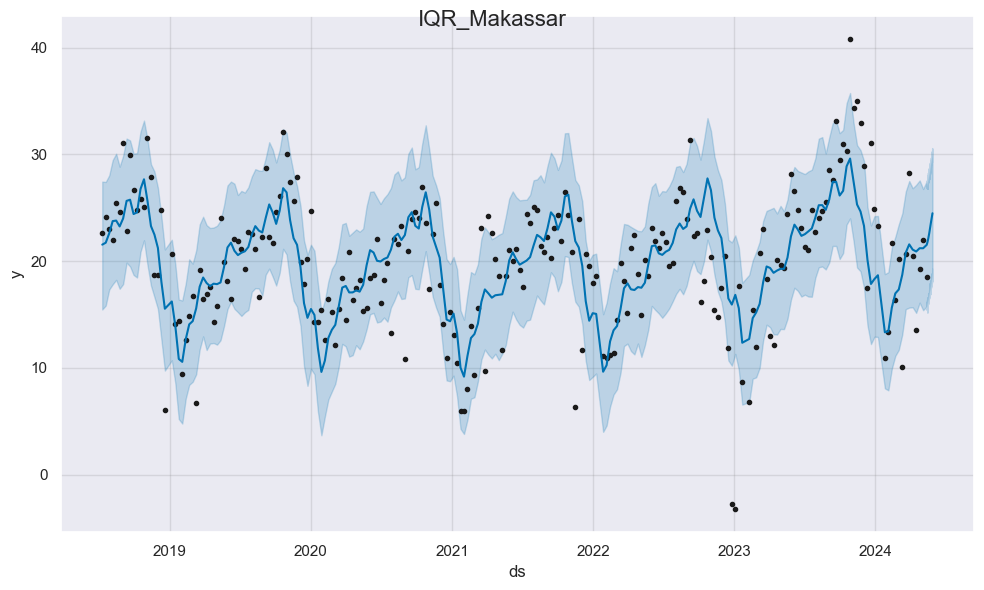

In [27]:
fig1 = model.plot(forecast)
fig1.suptitle('IQR_Makassar', fontsize=16)

c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:228: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst['ds'].dt.to_pydatetime()
c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:351: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  df_y['ds'].dt.to_pydatetime(), seas[name], ls='-', c='#0072B2')
c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\prophet\plot.py:354: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python d

Text(0.5, 0.98, 'IQR_Makassar')

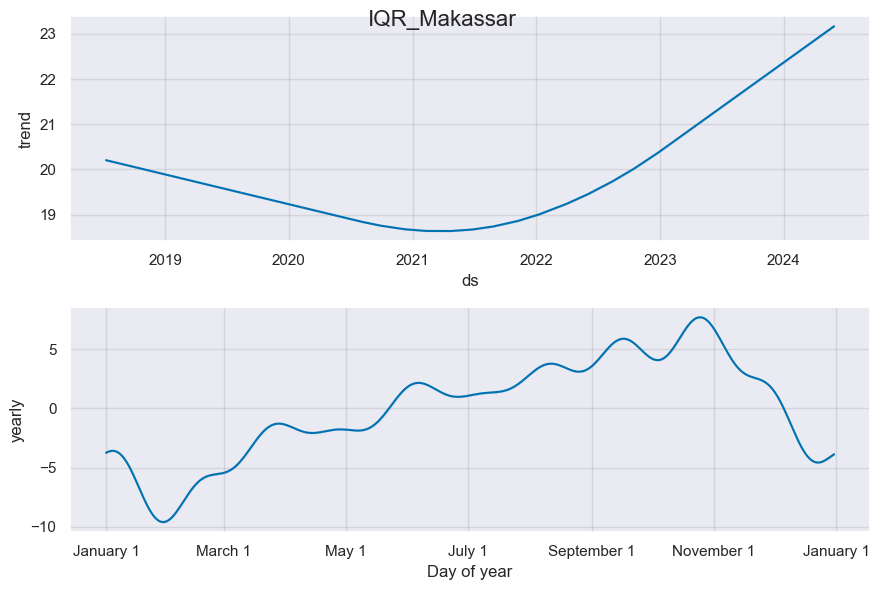

In [28]:
fig2 = model.plot_components(forecast)
fig2.suptitle('IQR_Makassar', fontsize=16)

In [61]:
from prophet.plot import plot_plotly, plot_components_plotly

fig3 = plot_plotly(model, forecast)
fig3.update_layout(title='IQR_Makassar', title_font_size=16,  title_x=0.5)

TypeError: cannot subtract DatetimeArray from ndarray

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_true = polusi['IQR_mks'].values
forecast = model.predict(future)
forecast [['ds', 'yhat','yhat_lower', 'yhat_upper']].tail()
y_pred = forecast
# Hitung RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE: {rmse}")

# Hitung R²
r2 = r2_score(y_true, forecast)
print(f"R²: {r2}")

# Plotting
fig1 = model.plot(forecast)
fig1.suptitle('IQR_Makassar', fontsize=16)

# Tambahkan nilai RMSE dan R² ke plot
plt.figtext(0.15, 0.85, f'RMSE: {rmse:.2f}', fontsize=12)
plt.figtext(0.15, 0.80, f'R²: {r2:.2f}', fontsize=12)

# Tampilkan plot
plt.show()


ValueError: Found input variables with inconsistent numbers of samples: [240, 599]

In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Ekstrak nilai aktual dari data
y_true = polusi['IQR_mks'].values

# Membuat dataframe masa depan yang mencakup semua tanggal dalam data asli
future = pd.DataFrame(date_time['ds'])

# Membuat prediksi
forecast = model.predict(future)

# Ekstrak nilai prediksi untuk periode yang sesuai dengan nilai aktual
# Menggunakan `merge` untuk memastikan kita hanya mengambil tanggal yang sesuai
merged = pd.concat(date_time, forecast[['ds', 'yhat']], on='ds')

# Pastikan panjang y_true dan y_pred sama
y_true = merged['IQR_mks'].values
y_pred = merged['yhat'].values

assert len(y_true) == len(y_pred), f"Length of y_true ({len(y_true)}) and y_pred ({len(y_pred)}) do not match."

# Hitung RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE: {rmse}")

# Hitung R²
r2 = r2_score(y_true, y_pred)
print(f"R²: {r2}")

# Plotting
fig1 = model.plot(forecast)
fig1.suptitle('IQR_Makassar', fontsize=16)

# Tambahkan nilai RMSE dan R² ke plot
plt.figtext(0.15, 0.85, f'RMSE: {rmse:.2f}', fontsize=12)
plt.figtext(0.15, 0.80, f'R²: {r2:.2f}', fontsize=12)

# Tampilkan plot
plt.show()


NameError: name 'polusi' is not defined

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Ekstrak nilai aktual dari data
y_true = polusi['IQR_mks']
y_pred = date_time['ds']

# Menggabungkan data berdasarkan kolom 'ds'
# Pastikan forecast 'ds' juga dalam format datetime
##forecast['ds'] = pd.to_datetime(forecast['ds'])
##merged = pd.merge(polusi, forecast[['ds', 'yhat']], on='ds')

# Ekstrak nilai prediksi untuk periode yang sesuai dengan nilai aktual
##y_true = merged['IQR_mks'].values
##y_pred = merged['yhat'].values

# Pastikan panjang y_true dan y_pred sama
##assert len(y_true) == len(y_pred), f"Length of y_true ({len(y_true)}) and y_pred ({len(y_pred)}) do not match."

# Hitung RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE: {rmse}")

# Hitung R²
r2 = r2_score(y_true, y_pred)
print(f"R²: {r2}")

# Plotting
fig1 = model.plot(forecast)
fig1.suptitle('IQR_Makassar', fontsize=16)

# Tambahkan nilai RMSE dan R² ke plot
plt.figtext(0.15, 0.85, f'RMSE: {rmse:.2f}', fontsize=12)
plt.figtext(0.15, 0.80, f'R²: {r2:.2f}', fontsize=12)

# Tampilkan plot
plt.show()


ValueError: Input contains NaN.

In [ ]:
proph = train.groupby(['date_block_num'])[ 'item_cnt_day'].sum()
proph.index=pd.date_range(start='2013-01-01', end='2015-10-01', freq='MS')
proph = proph.to_frame().reset_index()
proph.columns = ['ds', 'y']
proph.head()
#Modelling#
model=Prophet(yearly_seasonality=True)
model.fit(proph)
model.head()
#Making future predictions
future_data = model.make_future_dataframe(periods=1, freq='MS')
forecast = model.predict(future_data)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

In [57]:
y_true.head()

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [30]:
fig3 = plot_components_plotly(model, forecast)
fig3.update_layout(title='IQR_Makassar', title_font_size=16,  title_x=0.5)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'trend',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 7, 11, 0, 0),
                          datetime.datetime(2018, 7, 20, 0, 0),
                          datetime.datetime(2018, 7, 29, 0, 0), ...,
                          datetime.datetime(2024, 5, 28, 3, 0),
                          datetime.datetime(2024, 5, 28, 4, 0),
                          datetime.datetime(2024, 5, 28, 5, 0)], dtype=object),
              'xaxis': 'x',
              'y': array([20.20336717, 20.18707816, 20.17078916, ..., 23.16886557, 23.16909023,
                          23.1693149 ]),
              'yaxis': 'y'},
             {'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'yearly',
              'type': 'scatter',
              'x': array([datetime.datetime(2017, 1, 1, 0, 0),
                          datetime.datetime(2017, 1, 2, 0, 0, 59, 178082),
                          datetime.datetime(2017, 1, 3, 0, 1, 58, 356164), ...,
                          datetime.datetime(2017, 12, 29, 5, 57, 2, 465753),
                          datetime.datetime(2017, 12, 30, 5, 58, 1, 643835),
                          datetime.datetime(2017, 12, 31, 5, 59, 0, 821917)], dtype=object),
              'xaxis': 'x2',
              'y': array([-3.7434309 , -3.66225516, -3.60565229, ..., -4.07586299, -3.95650577,
                          -3.843552  ]),
              'yaxis': 'y2'}],
    'layout': {'height': 400,
               'showlegend': False,
               'template': '...',
               'title': {'font': {'size': 16}, 'text': 'IQR_Makassar', 'x': 0.5},
               'width': 900,
               'xaxis': {'anchor': 'y',
                         'domain': [0.0, 1.0],
                         'range': [2018-03-25 14:09:00, 2024-09-12 14:51:00],
                         'type': 'date'},
               'xaxis2': {'anchor': 'y2',
                          'domain': [0.0, 1.0],
                          'range': [2016-12-13 18:54:02.958904115, 2018-01-18
                                    11:04:57.863013581],
                          'tickformat': '%B %e',
                          'type': 'date'},
               'yaxis': {'anchor': 'x',
                         'domain': [0.575, 1.0],
                         'rangemode': 'normal',
                         'title': {'text': 'trend'},
                         'zerolinecolor': '#AAA'},
               'yaxis2': {'anchor': 'x2', 'domain': [0.0, 0.425], 'title': {'text': 'yearly'}, 'zerolinecolor': '#AAA'}}
})